In [43]:
import numpy as np
import pandas as pd

In [44]:
data=pd.read_csv('/content/IMDB Dataset.csv')


In [45]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [46]:
print(data.isnull().sum())

review       0
sentiment    0
dtype: int64


In [57]:
data.shape

(50000, 3)

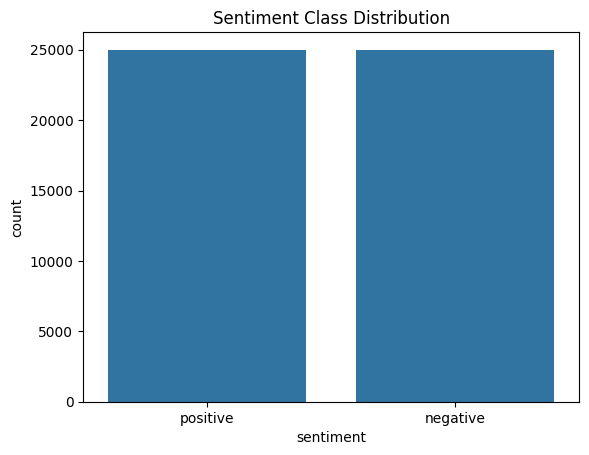

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x='sentiment', data=data)
plt.title('Sentiment Class Distribution')
plt.show()

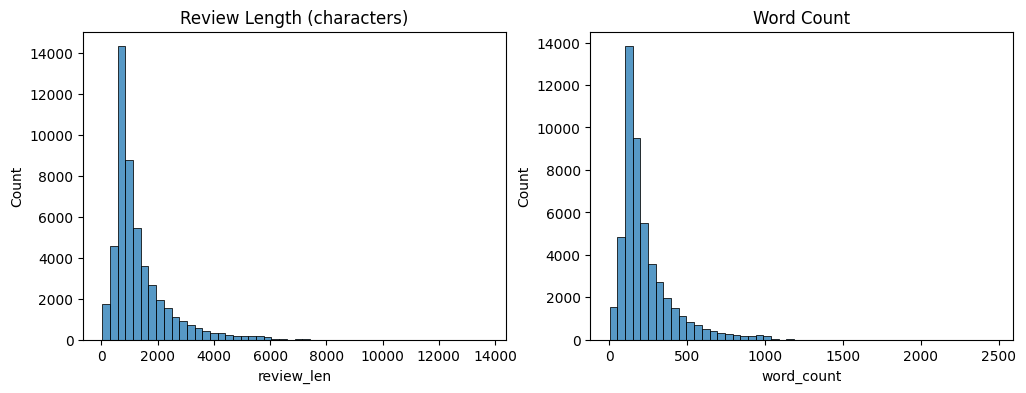

In [60]:
data['review_len'] = data['review'].apply(len)
data['word_count'] = data['review'].apply(lambda x: len(x.split()))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(data['review_len'], bins=50, ax=axes[0])
axes[0].set_title('Review Length (characters)')
sns.histplot(data['word_count'], bins=50, ax=axes[1])
axes[1].set_title('Word Count')
plt.show()

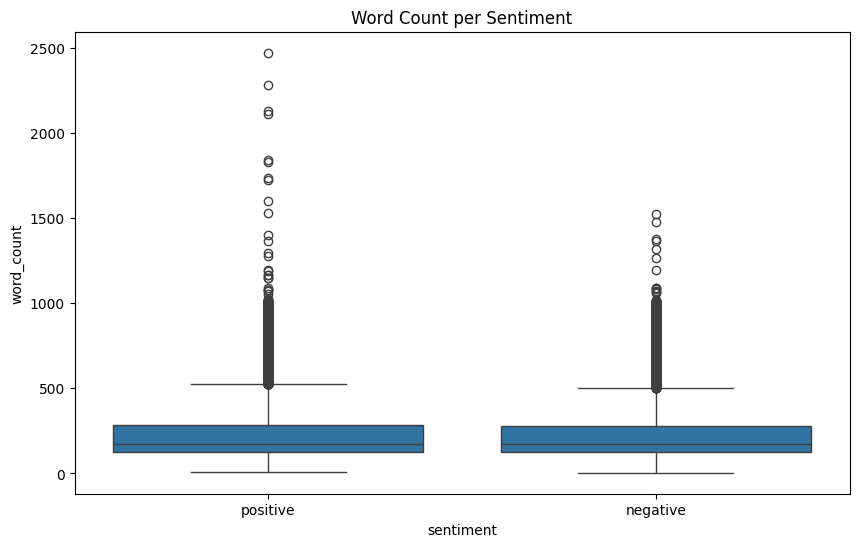

In [61]:
plt.figure(figsize=(10,6))
sns.boxplot(x='sentiment', y='word_count', data=data)
plt.title('Word Count per Sentiment')
plt.show()

In [64]:
!pip install wordcloud

In [66]:
from wordcloud import WordCloud
positive_sample = data[data['sentiment'] == 'positive']['review'].sample(n=2000, random_state=42)
negative_sample = data[data['sentiment'] == 'negative']['review'].sample(n=2000, random_state=42)
positive_text = ' '.join(positive_sample)
negative_text = ' '.join(negative_sample)

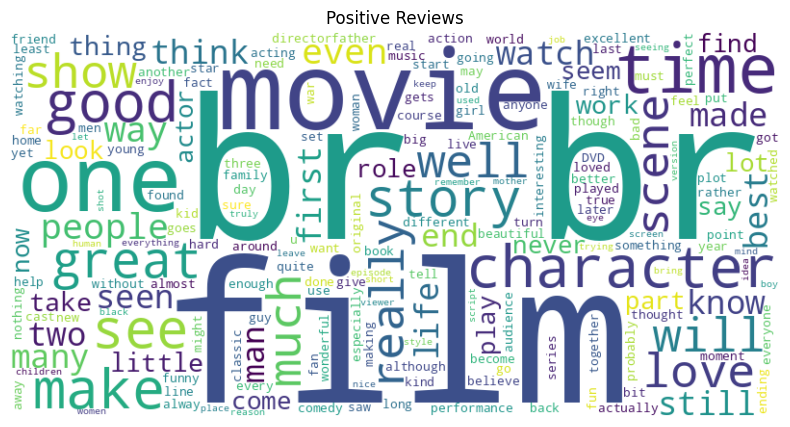

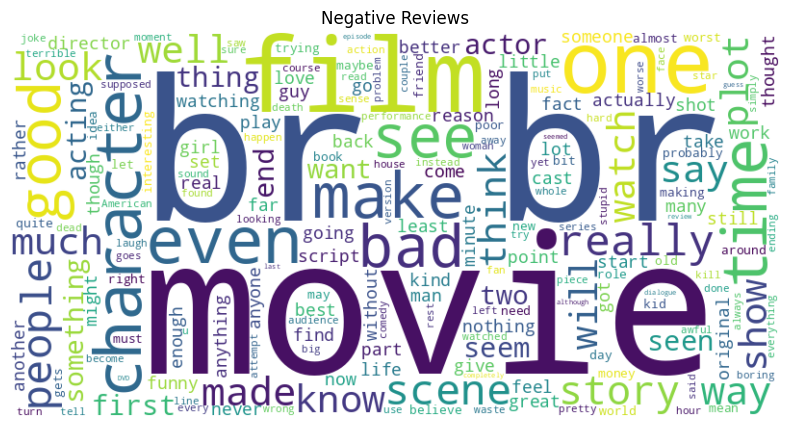

In [67]:
def plot_wordcloud(text, title):
    wc = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()
plot_wordcloud(positive_text, 'Positive Reviews')
plot_wordcloud(negative_text, 'Negative Reviews')

In [47]:
data.groupby('sentiment').describe()

review                                                            \
           count unique                                                top   
sentiment                                                                    
negative   25000  24698  Nickelodeon has gone down the toilet. They hav...   
positive   25000  24884  Loved today's show!!! It was a variety and not...   

                
          freq  
sentiment       
negative     3  
positive     5

In [48]:
data['negative']=data['sentiment'].apply(lambda x: 1 if x=='negative' else 0)
data.head()

,review,sentiment,negative
0,One of the other reviewers has mentioned that ...,positive,0
1,A wonderful little production. <br /><br />The...,positive,0
2,I thought this was a wonderful way to spend ti...,positive,0
3,Basically there's a family where a little boy ...,negative,1
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,0


In [49]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(data.review,data.sentiment,test_size=0.25)

In [50]:
from sklearn.feature_extraction.text import CountVectorizer
v = CountVectorizer()
x_train_count = v.fit_transform(x_train)
x_test_count = v.transform(x_test)





In [51]:
from sklearn.naive_bayes import MultinomialNB
model = MultinomialNB()
model.fit(x_train_count, y_train)

MultinomialNB()

In [52]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(x_test_count)
accuracy_score(y_test, y_pred)

0.84576

In [53]:
sentiment = [

           'Petter Matteis Love in the Time of Money ',
           'Basically theres a family where a little boy'

]
sentiment_count = v.transform(sentiment)
model.predict(sentiment_count)

array(['positive', 'positive'], dtype='<U8')

In [54]:
from sklearn.pipeline import Pipeline
clf = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nb', MultinomialNB())
])

In [55]:
clf.fit(x_train, y_train)

Pipeline(steps=[('vectorizer', CountVectorizer()), ('nb', MultinomialNB())])

In [56]:
import joblib
joblib.dump(clf, 'imdb_sentiment_model.pkl')

['imdb_sentiment_model.pkl']

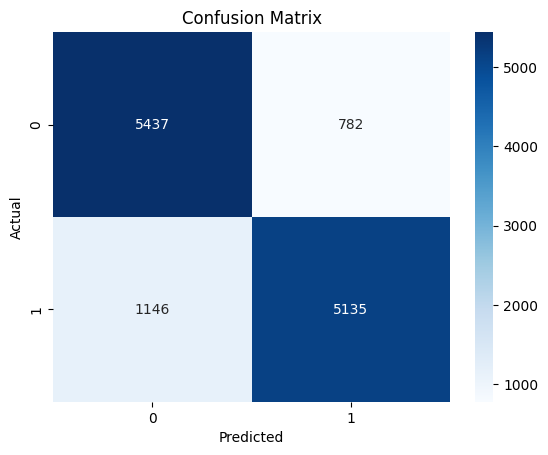

In [73]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()